<a href="https://colab.research.google.com/github/girishbetter/Machine-Learning-Models-for-Mobile-Price-Classification-/blob/main/Random_Forest_for_mobile_price_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Data Head:
    battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   



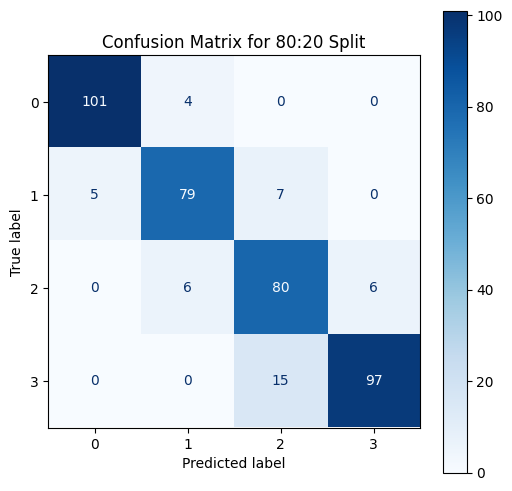


--- Evaluating Split: 70:30 (Train:Test) ---
Random Forest Accuracy: 0.8683


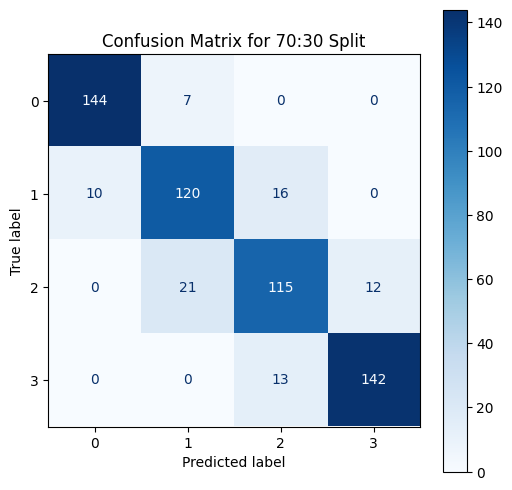


--- Visualization of Results ---


/tmp/ipykernel_8695/1054821439.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_labels, y=accuracies, palette='viridis')


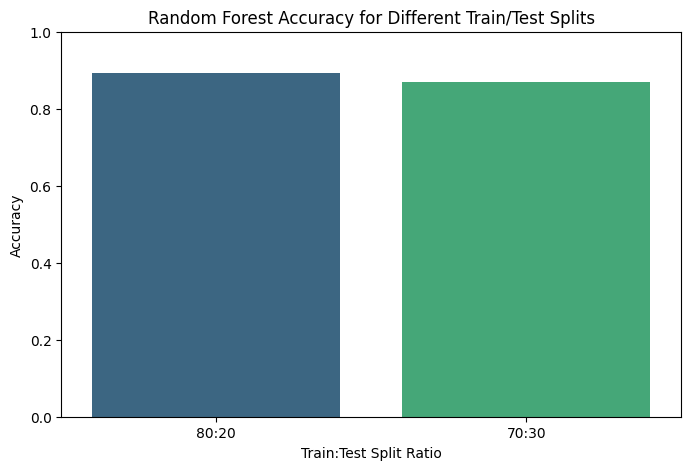

/tmp/ipykernel_8695/1054821439.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='mako')


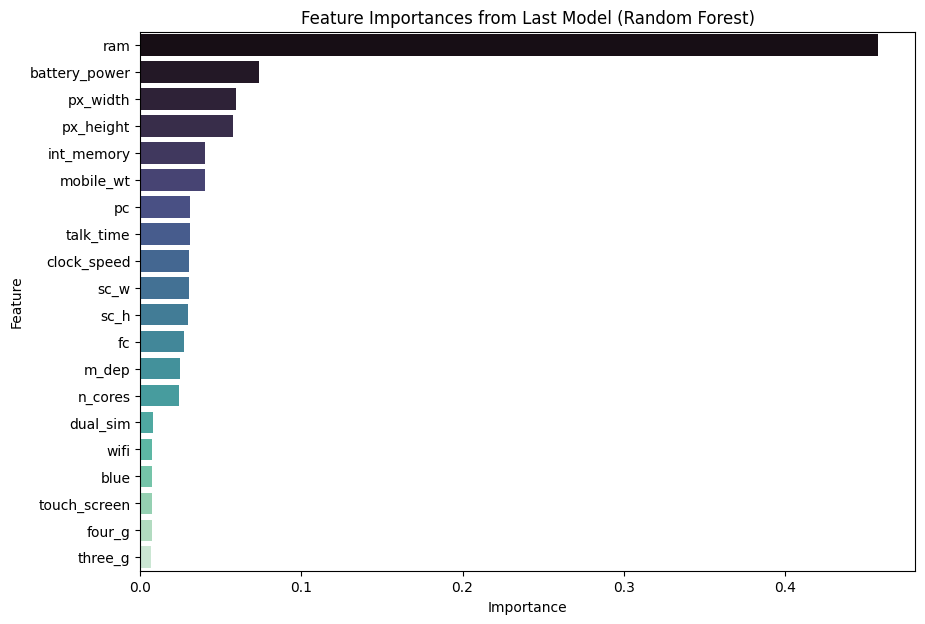

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mount drive and load data
drive.mount("/content/drive")
# Note: The file path refers to 'Housing.csv', but the data displayed below
#       appears to be a mobile phone dataset with features like 'battery_power', 'ram', 'price_range'.
#       Proceeding with the assumption that the loaded data is the mobile phone dataset.
path = "/content/drive/MyDrive/ML_DATASET/Housing.csv"
df = pd.read_csv(path)

# 2. Basic Data Exploration (Wrapped in print statements so they output in the console)
print("Data Head:\n", df.head(5))
print("\nMissing Values:\n", df[df.isnull().any(axis=1)])
print("\nData Info:")
df.info()

# 3. Separate features (X) and target (y)
X = df.drop("price_range", axis=1)
y = df["price_range"]

# Identify numerical columns for scaling
# Based on df.head(), these appear to be numerical and could benefit from scaling for some models.
numerical_cols = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt',
                  'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']

# Lists to store results for plotting
accuracies = []
split_labels = []
feature_importances = None # To store feature importances from the last model

# 4. Define the splits you want to test (0.2 = 80:20, 0.3 = 70:30)
test_sizes = [0.2, 0.3]

# 5. Loop through each split, train, evaluate, and visualize confusion matrix
for ts in test_sizes:
    # Calculate train/test percentages for the print statement
    train_pct = int((1 - ts) * 100)
    test_pct = int(ts * 100)
    split_label = f"{train_pct}:{test_pct}"
    split_labels.append(split_label)

    print(f"\n--- Evaluating Split: {split_label} (Train:Test) ---")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42)

    # --- Preprocessing: Scale numerical features ---
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Apply scaler only to numerical columns
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    # Initialize and train the model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict and calculate accuracy
    pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, pred)
    accuracies.append(accuracy)

    print(f"Random Forest Accuracy: {accuracy:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix for {split_label} Split')
    plt.show()

    # Store feature importances from the last model trained for later plotting
    if ts == test_sizes[-1]: # Only store for the last split
        feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# --- Graphs ---
print("\n--- Visualization of Results ---")

# 1. Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=split_labels, y=accuracies, palette='viridis')
plt.title('Random Forest Accuracy for Different Train/Test Splits')
plt.xlabel('Train:Test Split Ratio')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# 2. Feature Importance (from the last trained model)
if feature_importances is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='mako')
    plt.title('Feature Importances from Last Model (Random Forest)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()